Note: If you want to train the entire model in one stretch instead of clicking "Run All" in each notebook, you can run `train.py` instead. It's essentially the same thing!

# Analysis

Downloading data using the `mlcroissant` library

1. Kaggle twitter entity sentiment analysis dataset

In [26]:
import mlcroissant as mlc
import pandas as pd
import matplotlib.pyplot as plt

croissant_dataset = mlc.Dataset('https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis/croissant/download')

  -  [Metadata(Twitter Sentiment Analysis)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.


This is the raw data that is produced straight from the dataset

In [27]:
record_sets = croissant_dataset.metadata.record_sets
print(record_sets) # we have two datasets: "twitter_training" and "twitter_validation"

df1 = pd.DataFrame(croissant_dataset.records(record_set=record_sets[0].uuid))
df1.head()

[RecordSet(uuid="twitter_training.csv"), RecordSet(uuid="twitter_validation.csv")]


,twitter_training.csv/2401,twitter_training.csv/Borderlands,twitter_training.csv/Positive,twitter_training.csv/im+getting+on+borderlands+and+i+will+murder+you+all+%2C
0,2401,b'Borderlands',b'Positive',b'I am coming to the borders and I will kill y...
1,2401,b'Borderlands',b'Positive',b'im getting on borderlands and i will kill yo...
2,2401,b'Borderlands',b'Positive',b'im coming on borderlands and i will murder y...
3,2401,b'Borderlands',b'Positive',b'im getting on borderlands 2 and i will murde...
4,2401,b'Borderlands',b'Positive',b'im getting into borderlands and i can murder...


2. Hugging face Sentiment Analysis Complex

In [28]:
from datasets import load_dataset

ds = load_dataset("NNEngine/Sentiment-Analysis-Complex", split="train")

Raw data produced from second dataset:

In [29]:
df2 = ds.to_pandas()
df2.head()

,id,text,label
0,0,The interface remains modern friendly and high...,positive
1,1,This product creates a very frustrating and un...,negative
2,2,From installation to deployment everything fee...,positive
3,3,The design quality and performance together cr...,negative
4,4,The design quality and performance together #q...,positive


## Initial data analysis

### Dataset 1

Right now, looks like we have 4 available columns:
- ID??/Class id??? (unsure, not required)
- Company/Genre/Username (again, unsure. the dataset doesn't give a lot of information)
- Sentiment, classified as either `Positive`, `Negative`, `Neutral` or `Irrelevant`. In this dataset, it was recommended that `Irrelevant = Neutral`.
- The text content of the tweet. 

### Dataset 2

There are 3 columns:
- id (numerical id, not needed)
- text - the text content of the label
- label - the sentiment as a string

### Overall

To use this model, we only need two pieces of data: 
- Sentiment
- Text content (tokenised)

The others are not required/idk what they do/they probably won't help that much

# Quick cleanup of data

Some of the columns are not necessary at all. I will purge them and preppare for preprocessing

### Dataset 1

Firstly, lets remove the unnecessary columns we mentioned previously. Since this dataset is poorly formatted, we will have to remove it with these specific keywords. 

In [30]:
df = df1.drop(columns=['twitter_training.csv/2401', 'twitter_training.csv/Borderlands'])

Next, we drop the first row for the same reason

In [31]:
df = df.drop(index=0).reset_index(drop=True)

I add proper generic naming to the columns

In [32]:
df.columns = ['Sentiment', 'Text Content']

Now, we need to convert the text content as bytes to be able to modify the string content. 

In [33]:
df['Sentiment'] = df['Sentiment'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
df['Text Content'] = df['Text Content'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

In [34]:
df.head()

,Sentiment,Text Content
0,Positive,im getting on borderlands and i will kill you ...
1,Positive,im coming on borderlands and i will murder you...
2,Positive,im getting on borderlands 2 and i will murder ...
3,Positive,im getting into borderlands and i can murder y...
4,Positive,So I spent a few hours making something for fu...


Checking the head, we see a lot of positive borderlands content. I want to see other data, so I will reshuffle the data. It does not make a difference in training, but it makes analysis a lot more better.  

In [35]:
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,Sentiment,Text Content
0,Neutral,Home Depot and many white-collar workers are d...
1,Neutral,environmental conservation commitments are of ...
2,Irrelevant,The best gaming community.
3,Positive,Love Going to a Depot or a Low Coast
4,Negative,Borderlands 3 Update Delayed Due To Anti-Racis...


Now it's more nicer!

We need to remove any tweets/text that might be bad (NaN or empty) to remove the noise within the content

In [36]:
df = df[
    ~(
        df["Text Content"].fillna("").str.strip().eq("")
    )
].reset_index(drop=True)
df = df[df['Text Content'].str.strip().str.len() > 0].reset_index(drop=True)

Remove any duplicate data

In [37]:
print(f"before: {len(df)}")
print(f"duplicated: {df.duplicated(subset='Text Content').sum()}")

df = df.drop_duplicates(subset='Text Content').reset_index(drop=True)

print(f"after: {len(df)}")

before: 73822
duplicated: 4334
after: 69488


There may be some text that contains `<unk>`, which means "Unknown Token". Likely happened during parsing from the dataset creator. It's best to remove them. 

In [38]:
df['Text Content'] = df['Text Content'].str.replace('<unk>', '', regex=False)
df['Text Content'] = df['Text Content'].str.replace(r'\s+', ' ', regex=True).str.strip()
df = df[df['Text Content'].str.strip().str.len() > 0].reset_index(drop=True)

To make it compatible with our next dataset, lets make all the sentiments lowercased. 

In [39]:
df['Sentiment'] = df['Sentiment'].str.lower()

Now let's see it in its glory!

In [40]:
df1 = df
df1.head()

,Sentiment,Text Content
0,neutral,Home Depot and many white-collar workers are d...
1,neutral,environmental conservation commitments are of ...
2,irrelevant,The best gaming community.
3,positive,Love Going to a Depot or a Low Coast
4,negative,Borderlands 3 Update Delayed Due To Anti-Racis...


### Dataset 2

Dataset 2 is in its prepared form, so there is no need to decode or clean up the data. 

## Merge

In [41]:
df2 = df2.rename(columns={'label': 'Sentiment', 'text': 'Text Content'})

df2 = df2.drop(columns=['id'])

df = pd.concat([df1, df2], ignore_index=True)

In [42]:
df.head()

,Sentiment,Text Content
0,neutral,Home Depot and many white-collar workers are d...
1,neutral,environmental conservation commitments are of ...
2,irrelevant,The best gaming community.
3,positive,Love Going to a Depot or a Low Coast
4,negative,Borderlands 3 Update Delayed Due To Anti-Racis...


## Describing the dataset

In [43]:
df.describe()

,Sentiment,Text Content
count,8069487,8069487
unique,4,8069075
top,negative,.
freq,4021169,7


Our dataset has 73822 rows of twitter tweets, with 4 different sentiments. 

The sentiments are Positive, Negative, Neutral and Irrelevant. The creator of the dataset has stated to merge neutral and irrelevant together, or to remove irrelevant altogether. 

The top text content is completely random (as the dataset is shuffled), so there is no useful information from analysing this. 

The frequency is highly leaned towards a more negative side. This is typical to see within twitter (as twitter is stereotypically a place full of rantings and a place to put out anger). 

## Sentiment counts

In [44]:
print(df['Sentiment'].value_counts())

Sentiment
negative      4021169
positive      4019059
neutral         17041
irrelevant      12218
Name: count, dtype: int64


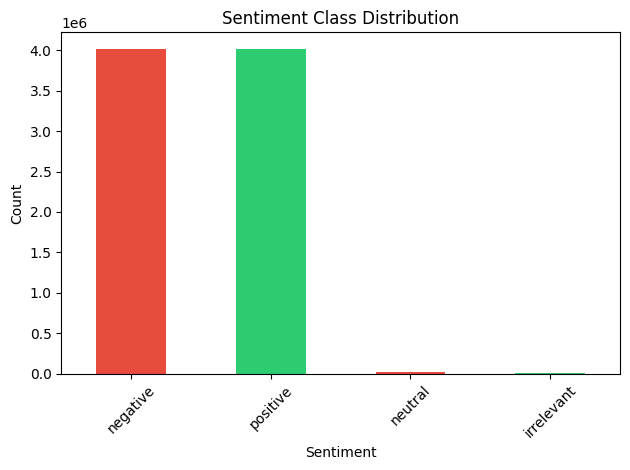

In [45]:
# disclaimer: block gen by ai
df['Sentiment'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Text character length

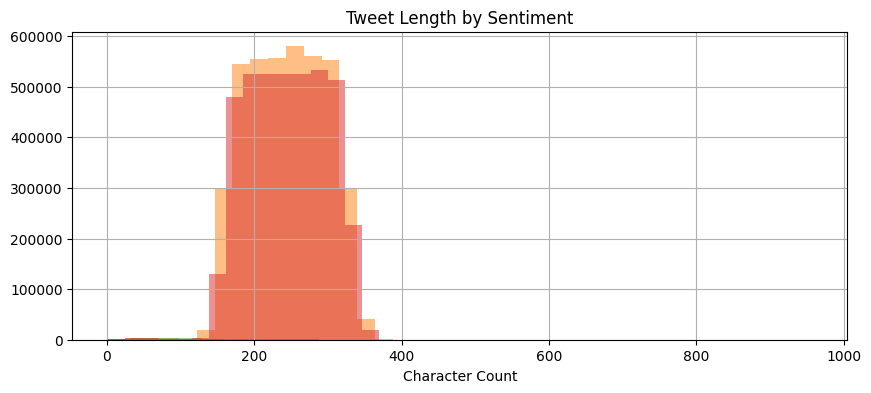

                count        mean        std  min     25%    50%    75%    max
Sentiment                                                                     
irrelevant    12218.0  113.384924  77.625135  2.0   53.25   94.0  157.0  426.0
negative    4021169.0  243.181861  52.113937  1.0  200.00  243.0  287.0  727.0
neutral       17041.0  122.144710  75.432953  1.0   66.00  108.0  164.0  957.0
positive    4019059.0  245.699226  52.526717  1.0  202.00  246.0  290.0  692.0


In [46]:
# disclaimer: block gen by ai
df['tweet_length'] = df['Text Content'].apply(len)

df.groupby('Sentiment')['tweet_length'].hist(alpha=0.5, bins=30, figsize=(10, 4))
plt.title('Tweet Length by Sentiment')
plt.xlabel('Character Count')
plt.show()

# Summary stats per class
print(df.groupby('Sentiment')['tweet_length'].describe())

Most text blocks have a character count of 245 character. 
- Neutral tweets have a max of 727 with an average of 243 characters. Such text blocks tend to be more descriptive/factual. 
- Positive tweets are shorter (max is 692 chars) as they mostly contain words of affirmation and gratitude. 

A high standard deviation suggests that character length cannot be used as a predictor, however it can potentially be used as a feature to sentiment. 

## Most common words

We can locate the most common words by using a library called `wordcloud`, which (as the name suggests) creates a cloud of data containing the words within the dataset, and its size increases for the word count. 

Since this model uses primarily negative and positive, we have removed neutral and irrelevant sentiments. 

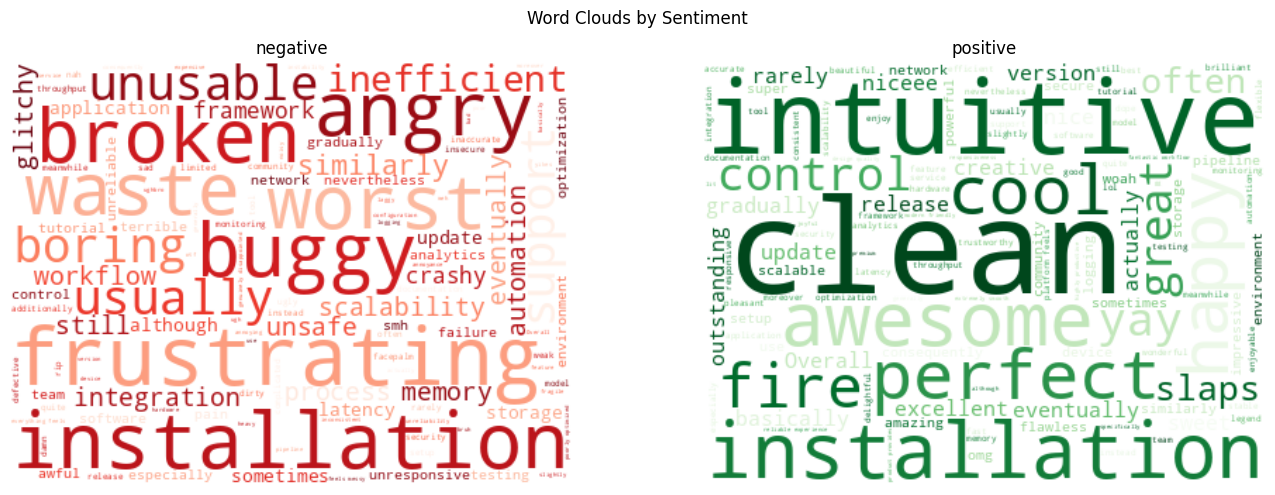

In [47]:
# disclaimer: block gen by ai
from wordcloud import WordCloud

df_filtered = df[df['Sentiment'].isin(['negative', 'positive'])]
df_s = df_filtered.sample(n=100_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colours = {'negative': 'Reds', 'positive': 'Greens'}

for ax, (sentiment, colour) in zip(axes.flatten(), colours.items()):
    text = ' '.join(df_s[df_s['Sentiment'] == sentiment]['Text Content'])
    wc = WordCloud(width=400, height=300,
                    colormap=colour, background_color='white').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(sentiment)
    ax.axis('off')

plt.suptitle('Word Clouds by Sentiment')
plt.tight_layout()
plt.show()

By the looks of it: 
- negative (the largest dataset) contains more swear words. There is a lot of words related to software, potentially showing that it may be related to gaming. 
- positive has mostly positive words (wow, shocker), with "cool" and "awesome" being strong. 

## Describing the data

In [48]:
df.describe()

,tweet_length
count,8.069487e+06
mean,2.439835e+02
std,5.298703e+01
min,1.000000e+00
25%,2.010000e+02
50%,2.440000e+02
75%,2.880000e+02
max,9.570000e+02


- Mean -> pretty average considering a tweet
- std -> high variation suggets there is large variation between tweets. 
- min -> 1 word
- max -> there may be some spammers that just spam text into their tweets. the dataset seems to have pulled it in. 

In [49]:
# block gen by ai
print(f"Total rows:     {len(df)}")
print(f"Duplicates:     {df.duplicated(subset='Text Content').sum()}")
print(f"Unique tweets:  {df['Text Content'].nunique()}")
print(f"Duplicate rate: {df.duplicated(subset='Text Content').sum() / len(df) * 100:.2f}%")

Total rows:     8069487
Duplicates:     412
Unique tweets:  8069075
Duplicate rate: 0.01%


# Export

After our initial analysis, let's export this for the next stage. 

In [50]:
import os
os.makedirs('csv', exist_ok=True)
df.to_parquet('csv/all_data.parquet', index=False, engine='pyarrow', compression='snappy')